In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline    

In [2]:
df=pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/thyroid-disease/thyroid0387.data')

In [3]:
df

,29,F,f,f.1,f.2,f.3,f.4,f.5,f.6,t,...,f.14,?.1,f.15,?.2,f.16,?.3,f.17,?.4,other,-[840801013]
0,29,F,f,f,f,f,f,f,f,f,...,t,128,f,?,f,?,f,?,other,-[840801014]
1,41,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,11,other,-[840801042]
2,36,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,26,other,-[840803046]
3,32,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,36,other,S[840803047]
4,60,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,26,other,-[840803048]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9166,56,M,f,f,f,f,f,f,f,f,...,t,64,t,0.83,t,77,f,?,SVI,-[870119022]
9167,22,M,f,f,f,f,f,f,f,f,...,t,91,t,0.92,t,99,f,?,SVI,-[870119023]
9168,69,M,f,f,f,f,f,f,f,f,...,t,113,t,1.27,t,89,f,?,SVI,I[870119025]
9169,47,F,f,f,f,f,f,f,f,f,...,t,75,t,0.85,t,88,f,?,other,-[870119027]


In [4]:
df.drop(['other'],axis='columns',inplace=True)

In [5]:
feature_columns=['age','sex','on_thyroxine','query_on_thyroxine','on_antithyroid_medication','sick','pregnant','thyroid_surgery','I131_treatment','query_hypothyroid','query_hyperthyroid','lithium','goitre','tumor','hypopituitary','psych','TSH_measured','TSH','T3_measured','T3','TT4_measured','TT4','T4U_measured','T4U','FTI_measured','FTI','TBG_measured','TBG','Target']

In [6]:
df.columns=feature_columns

In [7]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,Target
0,29,F,f,f,f,f,f,f,f,f,...,1.9,t,128,f,?,f,?,f,?,-[840801014]
1,41,F,f,f,f,f,f,f,f,f,...,?,f,?,f,?,f,?,t,11,-[840801042]
2,36,F,f,f,f,f,f,f,f,f,...,?,f,?,f,?,f,?,t,26,-[840803046]
3,32,F,f,f,f,f,f,f,f,f,...,?,f,?,f,?,f,?,t,36,S[840803047]
4,60,F,f,f,f,f,f,f,f,f,...,?,f,?,f,?,f,?,t,26,-[840803048]


# Data cleaning

In [8]:
for column in df:
    print(f'{column}:{df[column].unique()}')

age:[   29    41    36    32    60    77    28    54    42    51    37    16
    43    63    40    75    56    85    71    67    55    61    46    44
    82    64    70    33    59    53    52    49    35    48    27    69
    76    73    68    66    30    88    38    58    21    45    83    62
    25    86    72    14    15    39    26    20    80    90    23    18
    13    78    24    81    92    57    74     9    47    17    11    50
    34     8    79    31    65    84    12    10    19    22     1     2
    97     6    89    87   455    93     7    91     5    94     4 65511
    95 65512     3 65526]
sex:['F' 'M' '?']
on_thyroxine:['f' 't']
query_on_thyroxine:['f' 't']
on_antithyroid_medication:['f' 't']
sick:['f' 't']
pregnant:['f' 't']
thyroid_surgery:['f' 't']
I131_treatment:['f' 't']
query_hypothyroid:['f' 't']
query_hyperthyroid:['f' 't']
lithium:['f' 't']
goitre:['f' 't']
tumor:['f' 't']
hypopituitary:['f' 't']
psych:['f' 't']
TSH_measured:['t' 'f']
TSH:['1.6' '?' '0.7' '1.

In [9]:
target=df.Target
create=target.str.split('([A-Za-z]+)',expand=True)
create=create[1]
target=create.replace({None:'Z'})

In [10]:
df['Target']=target

In [11]:
df=df.replace(['?'],np.nan)

In [12]:
df.isna().sum()

age                             0
sex                           307
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
sick                            0
pregnant                        0
thyroid_surgery                 0
I131_treatment                  0
query_hypothyroid               0
query_hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH_measured                    0
TSH                           842
T3_measured                     0
T3                           2603
TT4_measured                    0
TT4                           441
T4U_measured                    0
T4U                           808
FTI_measured                    0
FTI                           801
TBG_measured                    0
TBG                          8822
Target                          0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        9171 non-null   int64 
 1   sex                        8864 non-null   object
 2   on_thyroxine               9171 non-null   object
 3   query_on_thyroxine         9171 non-null   object
 4   on_antithyroid_medication  9171 non-null   object
 5   sick                       9171 non-null   object
 6   pregnant                   9171 non-null   object
 7   thyroid_surgery            9171 non-null   object
 8   I131_treatment             9171 non-null   object
 9   query_hypothyroid          9171 non-null   object
 10  query_hyperthyroid         9171 non-null   object
 11  lithium                    9171 non-null   object
 12  goitre                     9171 non-null   object
 13  tumor                      9171 non-null   object
 14  hypopitu

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        9171 non-null   int64 
 1   sex                        8864 non-null   object
 2   on_thyroxine               9171 non-null   object
 3   query_on_thyroxine         9171 non-null   object
 4   on_antithyroid_medication  9171 non-null   object
 5   sick                       9171 non-null   object
 6   pregnant                   9171 non-null   object
 7   thyroid_surgery            9171 non-null   object
 8   I131_treatment             9171 non-null   object
 9   query_hypothyroid          9171 non-null   object
 10  query_hyperthyroid         9171 non-null   object
 11  lithium                    9171 non-null   object
 12  goitre                     9171 non-null   object
 13  tumor                      9171 non-null   object
 14  hypopitu

In [15]:
for column in df:
    print(f'{column}:{df[column].unique()}')

age:[   29    41    36    32    60    77    28    54    42    51    37    16
    43    63    40    75    56    85    71    67    55    61    46    44
    82    64    70    33    59    53    52    49    35    48    27    69
    76    73    68    66    30    88    38    58    21    45    83    62
    25    86    72    14    15    39    26    20    80    90    23    18
    13    78    24    81    92    57    74     9    47    17    11    50
    34     8    79    31    65    84    12    10    19    22     1     2
    97     6    89    87   455    93     7    91     5    94     4 65511
    95 65512     3 65526]
sex:['F' 'M' nan]
on_thyroxine:['f' 't']
query_on_thyroxine:['f' 't']
on_antithyroid_medication:['f' 't']
sick:['f' 't']
pregnant:['f' 't']
thyroid_surgery:['f' 't']
I131_treatment:['f' 't']
query_hypothyroid:['f' 't']
query_hyperthyroid:['f' 't']
lithium:['f' 't']
goitre:['f' 't']
tumor:['f' 't']
hypopituitary:['f' 't']
psych:['f' 't']
TSH_measured:['t' 'f']
TSH:['1.6' nan '0.7' '1.

In [16]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'Target'],
      dtype='object')

In [17]:
ft_col=['on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych']

In [18]:
for col in ft_col:
    df[col].replace({'f':0,'t':1},inplace=True)

In [19]:
df.drop(['TSH_measured','T3_measured','TT4_measured','T4U_measured','FTI_measured','TBG_measured','TBG'],axis='columns',inplace=True)

In [20]:
df.sex.replace({'F':1,'M':2},inplace=True)

In [21]:
df.sex.fillna(round(df.sex.mean()),inplace=True)

In [22]:
coll=['TSH','T3','TT4','T4U','FTI']

In [23]:
from sklearn.impute import KNNImputer
knn=KNNImputer(n_neighbors=3)

In [24]:
for col in coll:
    df[col]=knn.fit_transform(df[[col]])

In [25]:
for column in df:
    print(f'{column}:{df[column].unique()}')

age:[   29    41    36    32    60    77    28    54    42    51    37    16
    43    63    40    75    56    85    71    67    55    61    46    44
    82    64    70    33    59    53    52    49    35    48    27    69
    76    73    68    66    30    88    38    58    21    45    83    62
    25    86    72    14    15    39    26    20    80    90    23    18
    13    78    24    81    92    57    74     9    47    17    11    50
    34     8    79    31    65    84    12    10    19    22     1     2
    97     6    89    87   455    93     7    91     5    94     4 65511
    95 65512     3 65526]
sex:[1. 2.]
on_thyroxine:[0 1]
query_on_thyroxine:[0 1]
on_antithyroid_medication:[0 1]
sick:[0 1]
pregnant:[0 1]
thyroid_surgery:[0 1]
I131_treatment:[0 1]
query_hypothyroid:[0 1]
query_hyperthyroid:[0 1]
lithium:[0 1]
goitre:[0 1]
tumor:[0 1]
hypopituitary:[0 1]
psych:[0 1]
TSH:[1.60000000e+00 5.21899327e+00 7.00000000e-01 1.20000000e+00
 1.90000000e+00 1.00000000e+00 5.00000000e-0

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9171 non-null   int64  
 1   sex                        9171 non-null   float64
 2   on_thyroxine               9171 non-null   int64  
 3   query_on_thyroxine         9171 non-null   int64  
 4   on_antithyroid_medication  9171 non-null   int64  
 5   sick                       9171 non-null   int64  
 6   pregnant                   9171 non-null   int64  
 7   thyroid_surgery            9171 non-null   int64  
 8   I131_treatment             9171 non-null   int64  
 9   query_hypothyroid          9171 non-null   int64  
 10  query_hyperthyroid         9171 non-null   int64  
 11  lithium                    9171 non-null   int64  
 12  goitre                     9171 non-null   int64  
 13  tumor                      9171 non-null   int64

In [27]:
df.Target.value_counts()

Z      6770
K       436
G       359
I       346
F       233
R       196
A       147
L       115
M       111
N       110
S        85
GK       49
AK       46
J        30
B        21
C        18
MK       16
Q        14
O        14
KJ       11
GI       10
D         9
H         8
FK        6
P         5
MI        2
LJ        1
GKJ       1
OI        1
E         1
Name: Target, dtype: int64

hyperthyroid conditions (A, B, C, D)
	hypothyroid conditions (E, F, G, H)
	binding protein (I, J)
	general health (K)
	replacement therapy (L, M, N)
	discordant results (R)

In [28]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [29]:
dfle=df
dfle.Target=le.fit_transform(dfle.Target)

# Data Exploration

In [30]:
cor=df.corr()

In [31]:
cor

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,Target
age,1.000000,0.014175,-0.007097,-0.002530,-0.002832,-0.002416,-0.003892,-0.002631,-0.001646,-0.004254,...,-0.002733,-0.003746,-0.000600,-0.005211,-0.003979,0.003693,0.004122,-0.002045,0.004108,0.008899
sex,0.014175,1.000000,-0.100828,0.045180,-0.023991,0.009071,-0.071881,-0.039090,-0.009602,-0.070774,...,-0.003912,-0.074613,0.006277,0.099687,-0.036723,-0.048890,-0.150479,-0.214723,-0.030149,0.087962
on_thyroxine,-0.007097,-0.100828,1.000000,0.008248,-0.010513,-0.047850,0.010490,0.018289,0.071485,0.112228,...,0.002150,-0.009141,0.015756,-0.065004,0.009900,-0.000978,0.209424,0.049814,0.154467,0.018541
query_on_thyroxine,-0.002530,0.045180,0.008248,1.000000,-0.014743,-0.007791,0.017560,0.005424,-0.017847,-0.015136,...,0.014286,-0.005432,0.113387,-0.028464,-0.009699,-0.010018,-0.001771,-0.027608,0.013003,0.002965
on_antithyroid_medication,-0.002832,-0.023991,-0.010513,-0.014743,1.000000,-0.022344,0.024048,-0.005651,0.006257,-0.026853,...,-0.010882,-0.018594,-0.001672,-0.024734,-0.008574,0.086607,0.004485,0.042759,-0.021172,-0.002553
sick,-0.002416,0.009071,-0.047850,-0.007791,-0.022344,1.000000,-0.021449,-0.009691,-0.027049,0.005464,...,-0.018980,-0.003730,-0.002916,-0.032134,-0.019782,-0.062216,-0.033375,-0.021176,-0.025129,0.012535
pregnant,-0.003892,-0.071881,0.010490,0.017560,0.024048,-0.021449,1.000000,-0.004768,-0.014887,-0.021448,...,0.032190,0.102761,-0.001605,-0.014006,-0.015850,0.137196,0.130208,0.281776,-0.019433,-0.109325
thyroid_surgery,-0.002631,-0.039090,0.018289,0.005424,-0.005651,-0.009691,-0.004768,1.000000,0.003586,-0.000685,...,-0.011708,0.002719,-0.001798,-0.026610,0.014905,-0.008748,-0.010879,0.024903,-0.021282,0.029545
I131_treatment,-0.001646,-0.009602,0.071485,-0.017847,0.006257,-0.027049,-0.014887,0.003586,1.000000,0.052636,...,-0.013174,-0.022509,-0.002024,-0.029942,0.003894,0.019831,-0.006417,0.015159,-0.013172,-0.000133
query_hypothyroid,-0.004254,-0.070774,0.112228,-0.015136,-0.026853,0.005464,-0.021448,-0.000685,0.052636,1.000000,...,-0.017033,-0.025700,-0.004008,-0.036547,0.054678,-0.050484,-0.017913,0.017630,-0.032968,-0.061339


<AxesSubplot:>

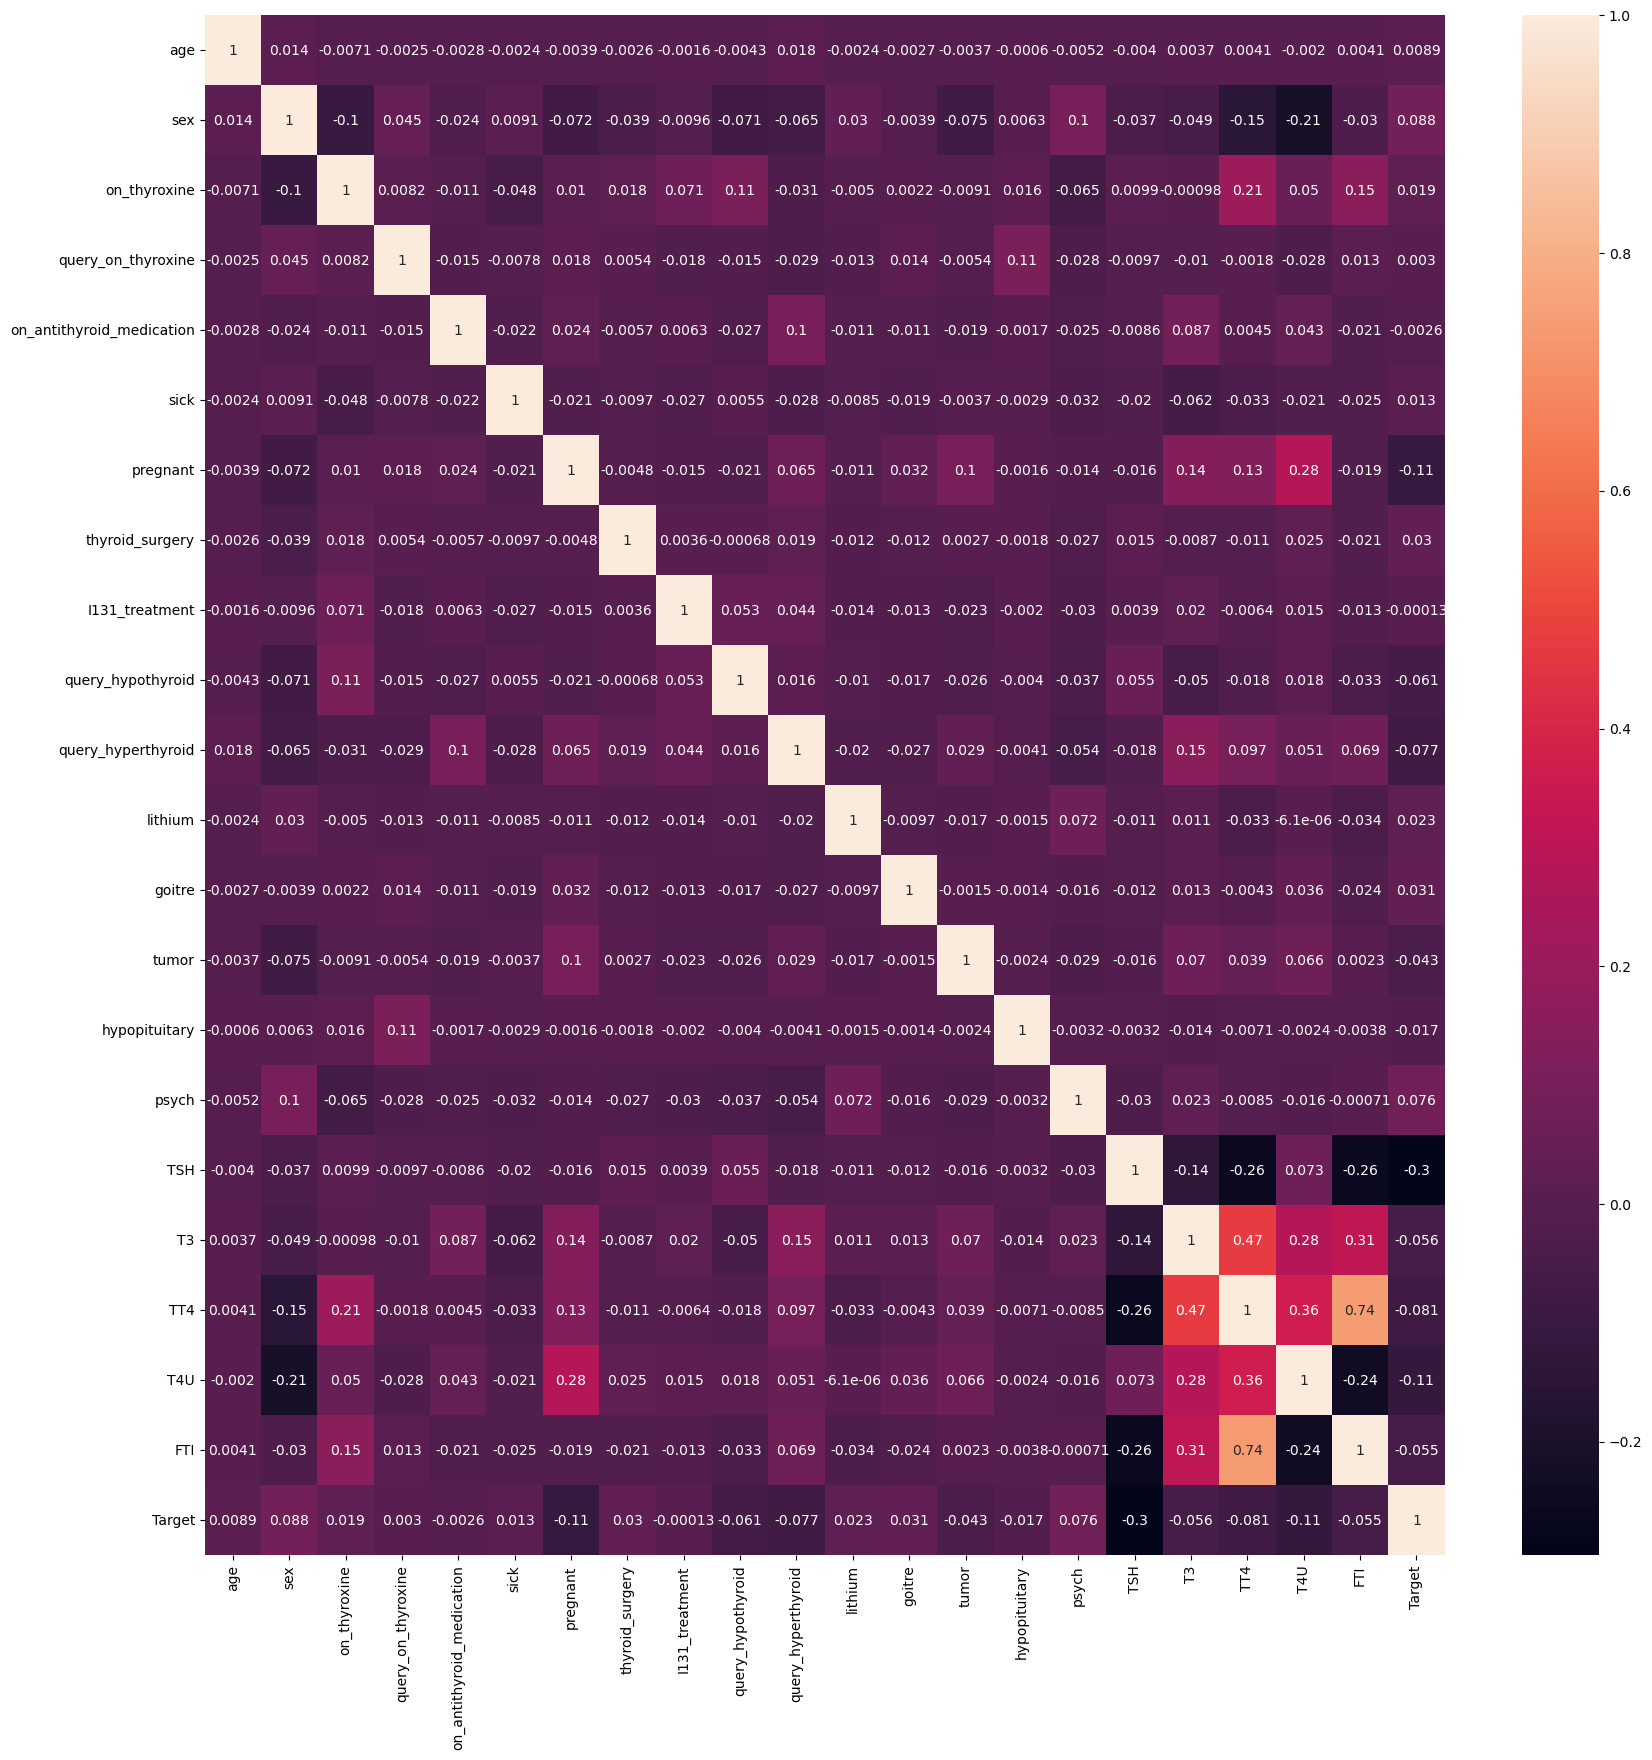

In [32]:
plt.figure(figsize=(20,20))
sns.heatmap(cor,annot=True)

array([[<AxesSubplot:title={'center':'age'}>,
        <AxesSubplot:title={'center':'sex'}>,
        <AxesSubplot:title={'center':'on_thyroxine'}>,
        <AxesSubplot:title={'center':'query_on_thyroxine'}>,
        <AxesSubplot:title={'center':'on_antithyroid_medication'}>],
       [<AxesSubplot:title={'center':'sick'}>,
        <AxesSubplot:title={'center':'pregnant'}>,
        <AxesSubplot:title={'center':'thyroid_surgery'}>,
        <AxesSubplot:title={'center':'I131_treatment'}>,
        <AxesSubplot:title={'center':'query_hypothyroid'}>],
       [<AxesSubplot:title={'center':'query_hyperthyroid'}>,
        <AxesSubplot:title={'center':'lithium'}>,
        <AxesSubplot:title={'center':'goitre'}>,
        <AxesSubplot:title={'center':'tumor'}>,
        <AxesSubplot:title={'center':'hypopituitary'}>],
       [<AxesSubplot:title={'center':'psych'}>,
        <AxesSubplot:title={'center':'TSH'}>,
        <AxesSubplot:title={'center':'T3'}>,
        <AxesSubplot:title={'center':'TT4'}>,

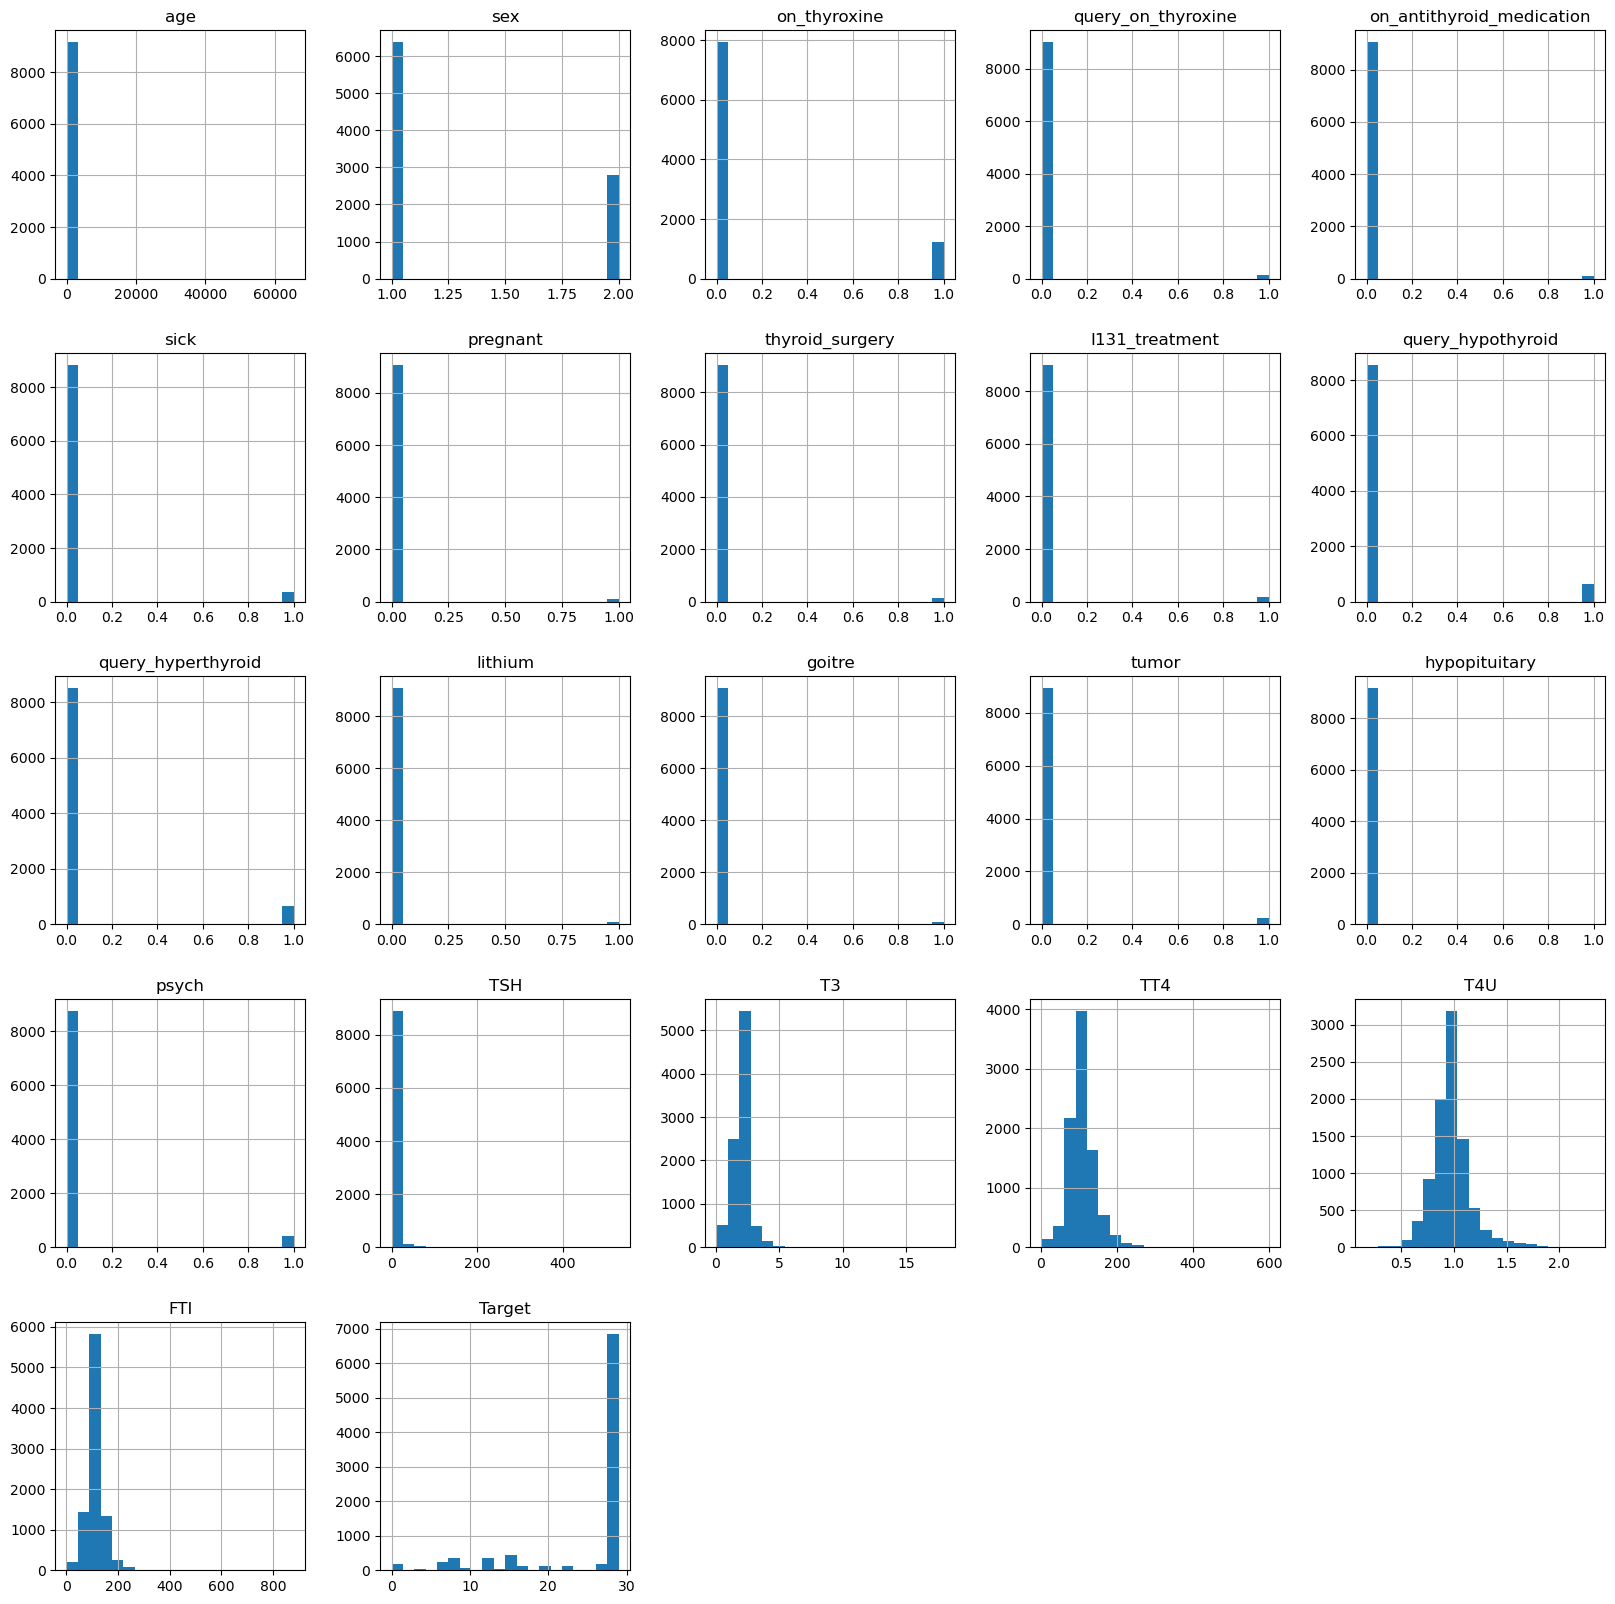

In [34]:
df.hist(bins=20,figsize=(20,20))

In [40]:
cols=['age','sex','TSH','T3','TT4','T4U','FTI']

In [41]:
from sklearn.preprocessing import MinMaxScaler
sca=MinMaxScaler()

In [42]:
for i in cols:
    df[i]=sca.fit_transform(df[[i]])

In [48]:
x=df.drop('Target',axis=1)
y=df.Target

In [49]:
from sklearn.decomposition import PCA

In [50]:
pca=PCA(0.95)

In [51]:
x_pca=pca.fit_transform(x)

In [52]:
x_pca.shape

(9171, 13)

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=16)

# Select best fitting model

In [55]:
from sklearn.metrics import accuracy_score

In [56]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [57]:
rf = RandomForestClassifier(n_estimators=20)
rclf = rf.fit(x_train,y_train)
y_pred = rclf.predict(x_test)
accuracy_score(y_pred,y_test)

0.9140863497601396

In [58]:
rf.score(x_test,y_test)

0.9140863497601396

neigh = KNeighborsClassifier(n_neighbors=5)
knnclf = neigh.fit(x_train,y_train)
y_pred = knnclf.predict(x_test)
accuracy_score(y_pred,y_test)

svm = SVC(kernel="sigmoid")
sclf = svm.fit(x_train,y_train)
y_pred = sclf.predict(x_test)
accuracy_score(y_pred,y_test)

tree = DecisionTreeClassifier(max_depth=3)
clf = tree.fit(x_train,y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_pred,y_test)

### Random forest classifier gives high accuracy score for this data 

In [59]:
from sklearn.metrics import classification_report,confusion_matrix

In [60]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.74      0.79        43
           1       0.80      0.67      0.73        12
           2       0.00      0.00      0.00         5
           3       1.00      0.17      0.29         6
           4       1.00      0.60      0.75         5
           6       0.93      0.98      0.95        54
           8       0.97      0.99      0.98        96
           9       1.00      0.33      0.50         3
          10       0.81      1.00      0.90        13
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.78      0.71      0.74        92
          14       0.00      0.00      0.00         6
          15       0.81      0.93      0.86       103
          17       0.61      0.58      0.59        33
          18       0.00      0.00      0.00         1
          19       0.97      0.91      0.94        35
          21       1.00    

C:\Users\soora\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\soora\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\soora\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [61]:
cm=confusion_matrix(y_test,y_pred)

Text(95.72222222222221, 0.5, 'Predicted')

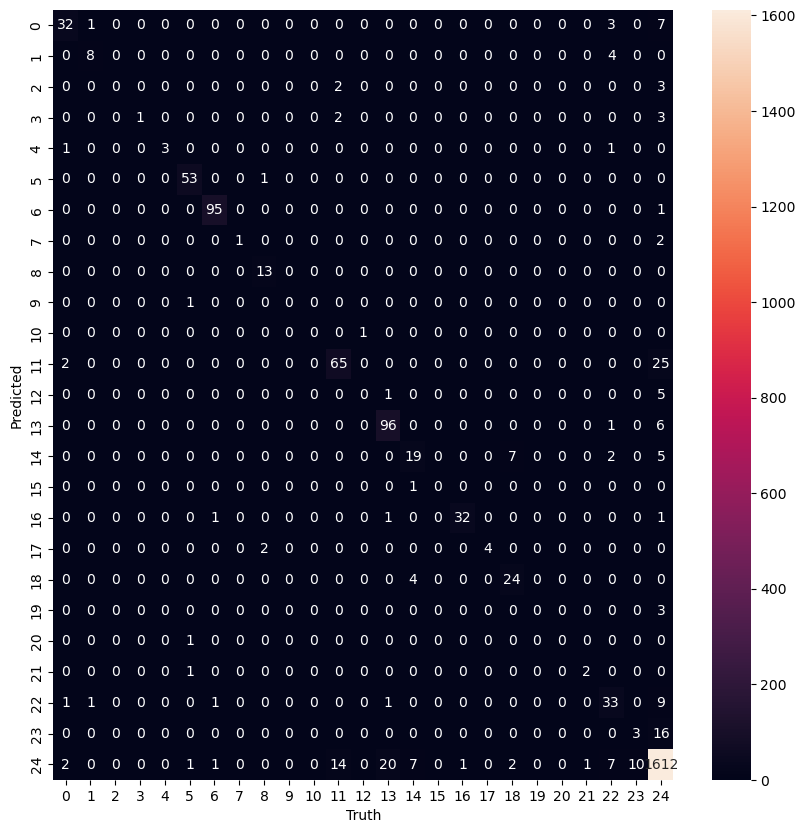

In [65]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Truth')
plt.ylabel('Predicted')

INSIGHTS: People having no thyroid disease is higher than the people with thyroid.
          41 people have hyperthyroid